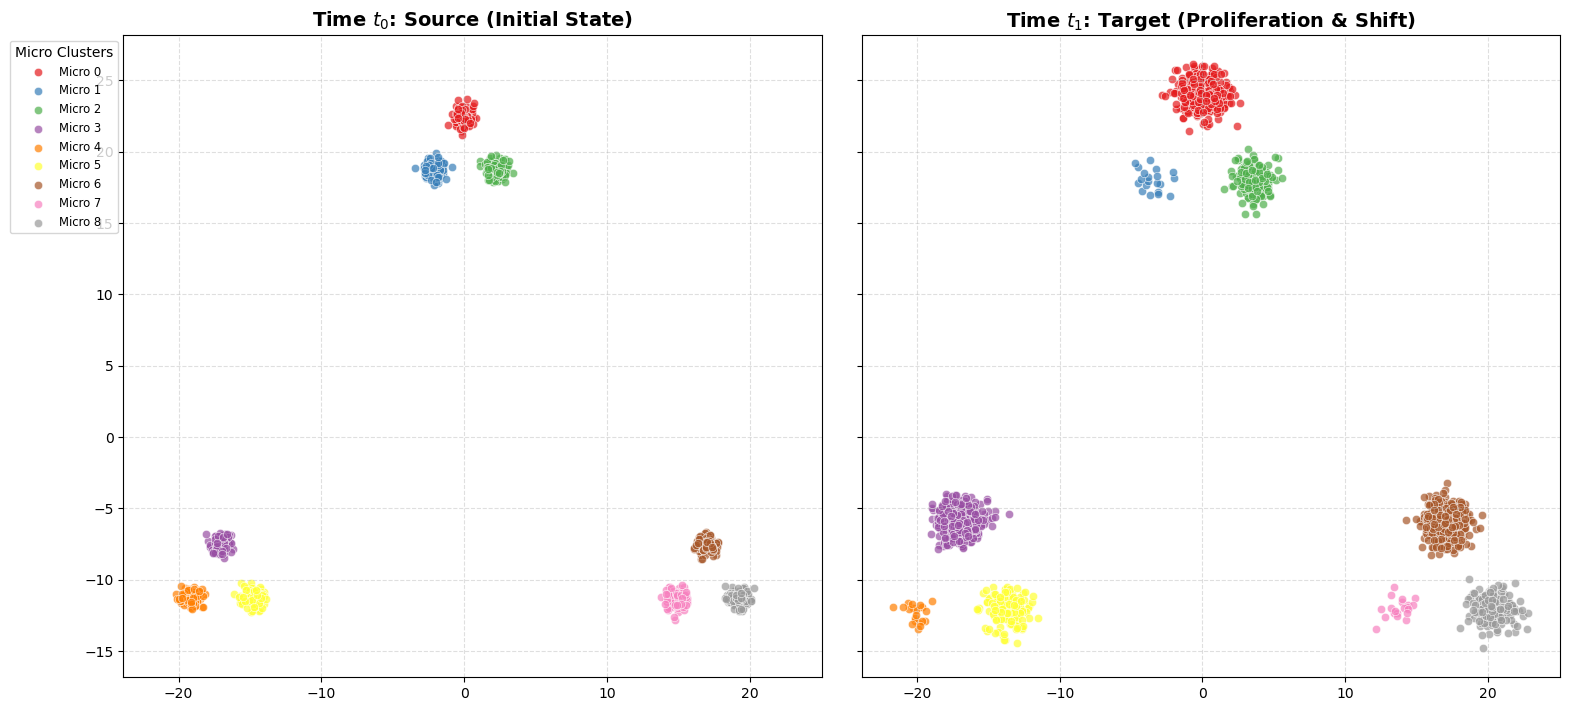

数据统计 (验证非平衡性):
micro_cluster_id    0    1    2    3    4    5    6    7    8
dataset_id                                                   
1                 100  100  100  100  100  100  100  100  100
2                 450   20  150  450   20  150  450   20  150


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_cellular_evolution_compatible():
    """
    生成兼容你 WFR-OET 计算框架的多尺度非平衡最优传输数据。
    - 列名已对齐: x, y, macro_cluster_id, micro_cluster_id, dataset_id
    """
    # 1. 宏观尺度 (Macro): 3个器官，分布在一个大三角形的顶点上
    macro_centers = {
        0: (0, 20),      # 器官 0 (顶部)
        1: (-17, -10),   # 器官 1 (左下)
        2: (17, -10)     # 器官 2 (右下)
    }
    
    # 2. 微观尺度 (Micro): 每个器官内有 3 种细胞亚型，呈小三角形分布
    micro_base_offsets = {
        0: (0, 2.5),             # 亚型 0: 靠上
        1: (-2.16, -1.25),       # 亚型 1: 靠左下
        2: (2.16, -1.25)         # 亚型 2: 靠右下
    }
    
    # 3. 演化参数设置 (dataset_id: 1 -> 2)
    # 定义非平衡的生长/凋亡比例
    growth_rates = {
        0: 4.5,  # 疯狂增殖
        1: 0.2,  # 逐渐凋亡
        2: 1.5   # 平稳生长
    }
    
    base_points = 100 # 源域的基础点数
    sigma_src = 0.4   # 源域分布紧密
    sigma_tgt = 0.8   # 目标域分布扩散 (异质性增加)
    
    data = []
    
    for macro_id, M_center in macro_centers.items():
        for micro_relative_id, offset in micro_base_offsets.items():
            
            # 全局唯一的小团 ID (0 到 8)
            global_micro_id = macro_id * 3 + micro_relative_id
            
            # ================= Source (dataset_id = 1) =================
            n_src = base_points
            cx_src = M_center[0] + offset[0]
            cy_src = M_center[1] + offset[1]
            
            pts_src = np.random.normal(loc=[cx_src, cy_src], scale=sigma_src, size=(n_src, 2))
            df_src = pd.DataFrame(pts_src, columns=['x', 'y'])
            df_src['macro_cluster_id'] = macro_id
            df_src['micro_cluster_id'] = global_micro_id
            df_src['dataset_id'] = 1  # <--- 对应你的源域标签
            data.append(df_src)
            
            # ================= Target (dataset_id = 2) =================
            n_tgt = int(n_src * growth_rates[micro_relative_id])
            
            # 形态偏移 (模拟分化)
            shift_multiplier = 1.6
            cx_tgt = M_center[0] + offset[0] * shift_multiplier
            cy_tgt = M_center[1] + offset[1] * shift_multiplier
            
            pts_tgt = np.random.normal(loc=[cx_tgt, cy_tgt], scale=sigma_tgt, size=(n_tgt, 2))
            df_tgt = pd.DataFrame(pts_tgt, columns=['x', 'y'])
            df_tgt['macro_cluster_id'] = macro_id
            df_tgt['micro_cluster_id'] = global_micro_id
            df_tgt['dataset_id'] = 2  # <--- 对应你的目标域标签
            data.append(df_tgt)
            
    return pd.concat(data, ignore_index=True)

# 生成 df_final 供后续直接使用
df_final = generate_cellular_evolution_compatible()
# df_final.to_csv('simulated_data_hierarchical.csv', index=False)

# ================= 可视化 =================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
times = [1, 2]
titles = ['Time $t_0$: Source (Initial State)', 'Time $t_1$: Target (Proliferation & Shift)']

# 使用柔和且对比强烈的颜色盘区分 9 个微观集群
cmap = plt.get_cmap('Set1') 

for i, t in enumerate(times):
    ax = axes[i]
    subset = df_final[df_final['dataset_id'] == t]
    
    for micro_id in sorted(subset['micro_cluster_id'].unique()):
        m_data = subset[subset['micro_cluster_id'] == micro_id]
        
        # 相同 micro_id 在两张图中颜色保持一致
        ax.scatter(m_data['x'], m_data['y'], 
                   color=cmap(micro_id % 9), 
                   alpha=0.7, edgecolors='w', linewidth=0.5,
                   label=f'Micro {micro_id}' if i == 0 else "")
        
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_aspect('equal')

axes[0].legend(loc='upper right', bbox_to_anchor=(0.0, 1.0), fontsize='small', title="Micro Clusters")
plt.tight_layout()
plt.show()

# 打印各小团在不同时刻的数量，验证 Unbalanced 特性
print("数据统计 (验证非平衡性):")
stats = df_final.groupby(['dataset_id', 'micro_cluster_id']).size().unstack(fill_value=0)
print(stats)

In [7]:
def compute_wfr_distance_unbalanced(gamma, mu_src, mu_tgt, M_points, delta=1.0):
    """
    计算 WFR 函数值
    """
    eps = 1e-10
    
    gamma_row_sum = gamma.sum(axis=1)
    gamma_col_sum = gamma.sum(axis=0)
    
    # 直接使用原始质量计算 KL
    # KL(γ_row || μ_src) = ∫ (γ_row * log(γ_row/μ_src) - γ_row + μ_src)
    # 对于离散分布: Σ [γ_row * log(γ_row/μ_src) - γ_row + μ_src]
    kl_src = np.sum(gamma_row_sum * (np.log(gamma_row_sum + eps) - np.log(mu_src + eps)) 
                    - gamma_row_sum + mu_src)
    kl_tgt = np.sum(gamma_col_sum * (np.log(gamma_col_sum + eps) - np.log(mu_tgt + eps))
                    - gamma_col_sum + mu_tgt)
    
    integral_term = np.sum(M_points * gamma)
    
    wfr_squared = 2 * delta**2 * (integral_term + kl_src + kl_tgt)
    
    return wfr_squared, np.sqrt(wfr_squared)


--- Running Level 3: Point Scale OT ---
Solving final point-wise OT (this might take a few seconds)...


/home1/clz/.conda/envs/stUAI/lib/python3.10/site-packages/ot/backend.py:1584: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  jax.device_put(jnp.array(1, dtype=jnp.float64), d),


代码运行耗时: 1.432067 秒
Plotting 5694 connections...


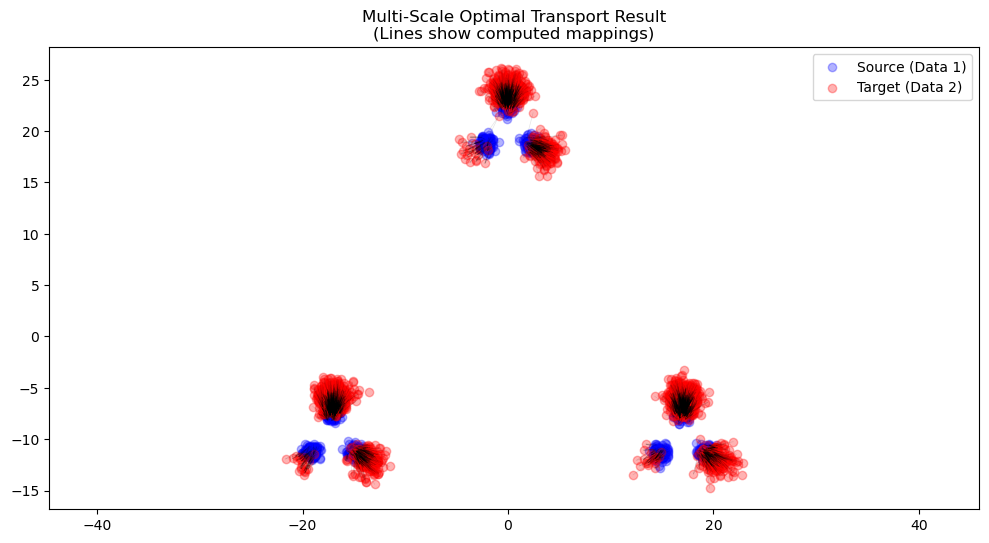


=== WFR Distance Computation ===
WFR^2: 1999.008538
WFR distance: 44.710273


In [8]:
""" 
精确 UOT
delta = 1
"""
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ot  # Python Optimal Transport library
from scipy.spatial.distance import cdist

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

# ================= 0. 数据准备 (沿用上一段代码生成的数据) =================
# 假设 df_final 已经在内存中，或者我们重新加载它
# df_final = pd.read_csv('simulated_data_hierarchical_unbalanced.csv') 

# 分离 Source (Data 1) 和 Target (Data 2)
df_src = df_final[df_final['dataset_id'] == 1].copy().reset_index(drop=True)  # 起点
df_tgt = df_final[df_final['dataset_id'] == 2].copy().reset_index(drop=True)  # 终点

# 提取坐标数组
X_src = df_src[['x', 'y']].values
X_tgt = df_tgt[['x', 'y']].values

# ================= 3. Level 3: Point Scale (点级别) =================

print("\n--- Running Level 3: Point Scale OT ---")

# 3.1 权重 (均匀分布)
n_src = len(df_src)
n_tgt = len(df_tgt)
w_points_src = np.ones(n_src)  
w_points_tgt = np.ones(n_tgt)  

delta = 1

norm_2_dist = ot.dist(X_src, X_tgt, metric='euclidean')
cos_sq = np.cos(np.minimum(norm_2_dist / (2 * delta), np.pi/2))**2
M_points = -np.log(np.where(cos_sq == 0, 1e-10, cos_sq))

# 3.4 求解 Level 3 OT
print("Solving final point-wise OT (this might take a few seconds)...")

w_points_src_cuda = torch.from_numpy(w_points_src).to(device)
w_points_tgt_cuda = torch.from_numpy(w_points_tgt).to(device)
M_points_cuda = torch.from_numpy(M_points).to(device)

start_time = time.perf_counter()

gamma_points_full_batch = ot.unbalanced.mm_unbalanced(w_points_src_cuda, w_points_tgt_cuda, M_points_cuda, reg_m=[1.0,1.0])

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"代码运行耗时: {elapsed_time:.6f} 秒")

gamma_points_full_batch = gamma_points_full_batch.cpu().numpy()

# ================= 4. 最终结果可视化 =================
plt.figure(figsize=(12, 6))

# 绘制 Source 和 Target 点
plt.scatter(X_src[:, 0], X_src[:, 1], c='blue', alpha=0.3, label='Source (Data 1)')
plt.scatter(X_tgt[:, 0], X_tgt[:, 1], c='red', alpha=0.3, label='Target (Data 2)')

# 绘制传输连接线
# 为了图像不至于太乱，我们只画出传输权重最大的那些连接 (或者随机采样)
# 这里的 gamma_points 是稀疏的，且数值很小 (大约 1/N)
# 我们画出所有 gamma > 0 的线
mx = gamma_points_full_batch.max()
idx_struct = np.argwhere(gamma_points_full_batch > mx * 0.01) 
# idx_struct = np.argwhere(gamma_points_full_batch > 0)  # 阈值过滤

print(f"Plotting {len(idx_struct)} connections...")

for i, j in idx_struct:
    # 绘制从 src[i] 到 tgt[j] 的线
    plt.plot([X_src[i, 0], X_tgt[j, 0]], [X_src[i, 1], X_tgt[j, 1]],
             c='k', alpha=0.1, linewidth=0.5)

plt.title("Multi-Scale Optimal Transport Result\n(Lines show computed mappings)")
plt.legend()
plt.axis('equal')
plt.show()

# ================= 5. 最终 WFR 函数值 =================
# 计算 WFR 距离
wfr_squared, wfr_distance = compute_wfr_distance_unbalanced(
    gamma=gamma_points_full_batch,
    mu_src=w_points_src,
    mu_tgt=w_points_tgt,
    M_points=M_points,
    delta=delta
)

print(f"\n=== WFR Distance Computation ===")
print(f"WFR^2: {wfr_squared:.6f}")
print(f"WFR distance: {wfr_distance:.6f}")

Computing cost matrix...
Running mini-batch WFR-OET with 2 batches...
代码运行耗时: 0.428308 秒
Plotting 3369 connections...


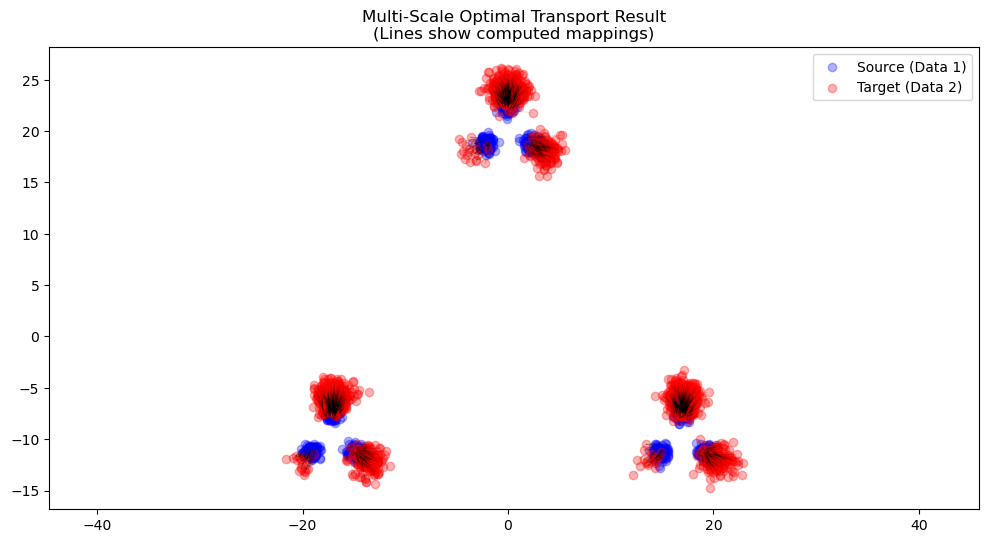


=== WFR Distance Computation ===
WFR^2: 2508.765750
WFR distance: 50.087581


In [9]:
""" 
mini-batch UOT
delta = 1
"""
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ot  # Python Optimal Transport library

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

# ================= 0. 数据准备 =================
# df_final = pd.read_csv('simulated_data_hierarchical_unbalanced.csv') 

df_src = df_final[df_final['dataset_id'] == 1].copy().reset_index(drop=True)
df_tgt = df_final[df_final['dataset_id'] == 2].copy().reset_index(drop=True)

X_src = df_src[['x', 'y']].values
X_tgt = df_tgt[['x', 'y']].values

# 点数（你原代码缺的）
n_src = len(df_src)
n_tgt = len(df_tgt)

# 权重
w_src = np.ones(n_src)
w_tgt = np.ones(n_tgt)

# ================= 1. 成本矩阵 =================
print("Computing cost matrix...")

delta = 1.0

norm_2_dist = ot.dist(X_src, X_tgt, metric='euclidean')
cos_val = np.cos(np.minimum(norm_2_dist / (2 * delta), np.pi / 2))
cos_sq = np.maximum(cos_val ** 2, 1e-10)
M_points = -2 * np.log(cos_sq)

# ================= 2. mini-batch UOT =================
chunk_size = 500

group_number = n_src // chunk_size + 1

# 打乱
src_perm = np.random.permutation(n_src)
tgt_perm = np.random.permutation(n_tgt)

# 分组
src_indices = np.array_split(src_perm, group_number)
tgt_indices = np.array_split(tgt_perm, group_number)

# 初始化 coupling
G = np.zeros((n_src, n_tgt), dtype=np.float32)

print(f"Running mini-batch WFR-OET with {group_number} batches...")

start_time = time.perf_counter()

# zip 一一对应
for k, (src_idx, tgt_idx) in enumerate(zip(src_indices, tgt_indices)):
    sub_cost = M_points[np.ix_(src_idx, tgt_idx)]
    sub_a = w_src[src_idx]
    sub_b = w_tgt[tgt_idx]
    
    # tensor
    sub_a_tensor = torch.from_numpy(sub_a).float().to(device)
    sub_b_tensor = torch.from_numpy(sub_b).float().to(device)
    sub_cost_tensor = torch.from_numpy(sub_cost).float().to(device)
    
    # UOT 求解
    G_sub = ot.unbalanced.mm_unbalanced(
        sub_a_tensor,
        sub_b_tensor,
        sub_cost_tensor,
        reg_m=[1.0, 1.0]
    )
    
    if torch.is_tensor(G_sub):
        G_sub = G_sub.cpu().numpy()
    
    # 写入
    G[np.ix_(src_idx, tgt_idx)] = G_sub
    
    if (k + 1) % 10 == 0:
        print(f"  Batch ({k+1}/{group_number})")

end_time = time.perf_counter()
print(f"代码运行耗时: {end_time - start_time:.6f} 秒")

# ================= 4. 可视化 =================
plt.figure(figsize=(12, 6))

plt.scatter(X_src[:, 0], X_src[:, 1], c='blue', alpha=0.3, label='Source (Data 1)')
plt.scatter(X_tgt[:, 0], X_tgt[:, 1], c='red', alpha=0.3, label='Target (Data 2)')

mx = G.max()
idx_struct = np.argwhere(G > mx * 0.01)

print(f"Plotting {len(idx_struct)} connections...")

for i, j in idx_struct:
    plt.plot(
        [X_src[i, 0], X_tgt[j, 0]],
        [X_src[i, 1], X_tgt[j, 1]],
        c='k', alpha=0.1, linewidth=0.5
    )

plt.title("Multi-Scale Optimal Transport Result\n(Lines show computed mappings)")
plt.legend()
plt.axis('equal')
plt.show()

# ================= 5. WFR 距离 =================
wfr_squared, wfr_distance = compute_wfr_distance_unbalanced(
    G, w_src, w_tgt, M_points, delta
)

print(f"\n=== WFR Distance Computation ===")
print(f"WFR^2: {wfr_squared:.6f}")
print(f"WFR distance: {wfr_distance:.6f}")


--- Running Level 3: Point Scale OT ---
Solving final point-wise OT (this might take a few seconds)...
代码运行耗时: 0.030431 秒
Plotting 3994 connections...


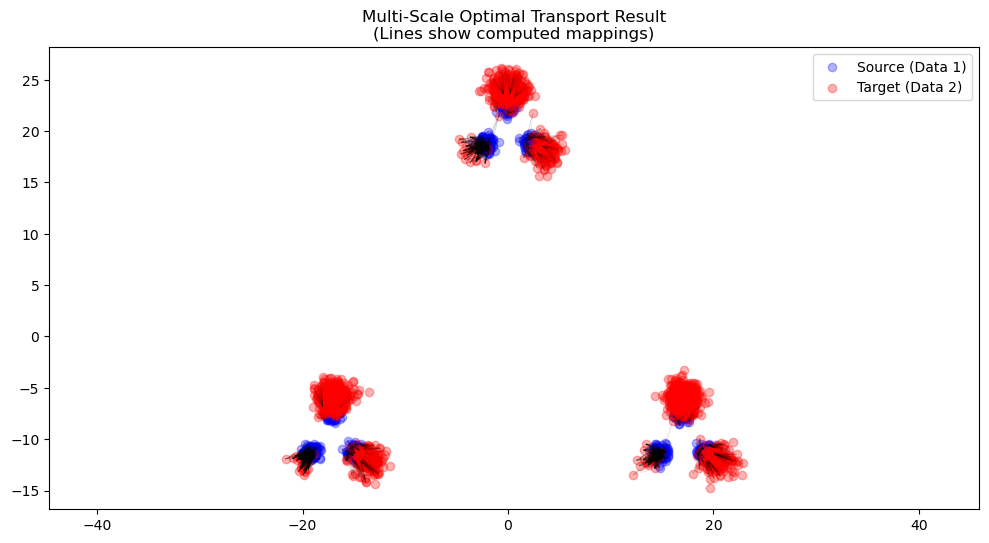


=== WFR Distance Computation ===
WFR^2: 5704.726460
WFR distance: 75.529640


In [10]:
""" 
Sinkhorn UOT
delta = 1
"""
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ot  # Python Optimal Transport library
from scipy.spatial.distance import cdist

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

# ================= 0. 数据准备 (沿用上一段代码生成的数据) =================
# 假设 df_final 已经在内存中，或者我们重新加载它
# df_final = pd.read_csv('simulated_data_hierarchical_unbalanced.csv') 

# 分离 Source (Data 1) 和 Target (Data 2)
df_src = df_final[df_final['dataset_id'] == 1].copy().reset_index(drop=True)  # 起点
df_tgt = df_final[df_final['dataset_id'] == 2].copy().reset_index(drop=True)  # 终点

# 提取坐标数组
X_src = df_src[['x', 'y']].values
X_tgt = df_tgt[['x', 'y']].values

# ================= 3. Level 3: Point Scale (点级别) =================

print("\n--- Running Level 3: Point Scale OT ---")

# 3.1 权重 (均匀分布)
n_src = len(df_src)
n_tgt = len(df_tgt)
w_points_src = np.ones(n_src)  
w_points_tgt = np.ones(n_tgt)  

delta = 1

norm_2_dist = ot.dist(X_src, X_tgt, metric='euclidean')
cos_sq = np.cos(np.minimum(norm_2_dist / (2 * delta), np.pi/2))**2
M_points = -np.log(np.where(cos_sq == 0, 1e-10, cos_sq))

# 3.4 求解 Level 3 OT
print("Solving final point-wise OT (this might take a few seconds)...")

reg = 0.5
reg_m = 1.0

start_time = time.perf_counter()

gamma_points_full_batch = ot.unbalanced.sinkhorn_unbalanced(
    w_points_src,
    w_points_tgt,
    M_points,
    reg,
    reg_m,
    stopThr=1e-6
)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"代码运行耗时: {elapsed_time:.6f} 秒")

# ================= 4. 最终结果可视化 =================
plt.figure(figsize=(12, 6))

# 绘制 Source 和 Target 点
plt.scatter(X_src[:, 0], X_src[:, 1], c='blue', alpha=0.3, label='Source (Data 1)')
plt.scatter(X_tgt[:, 0], X_tgt[:, 1], c='red', alpha=0.3, label='Target (Data 2)')

# 绘制传输连接线
# 为了图像不至于太乱，我们只画出传输权重最大的那些连接 (或者随机采样)
# 这里的 gamma_points 是稀疏的，且数值很小 (大约 1/N)
# 我们画出所有 gamma > 0 的线
mx = gamma_points_full_batch.max()
# idx_struct = np.argwhere(gamma_points_full_batch > 0)
idx_struct = np.argwhere(gamma_points_full_batch > mx * 0.2) 

print(f"Plotting {len(idx_struct)} connections...")

for i, j in idx_struct:
    # 绘制从 src[i] 到 tgt[j] 的线
    plt.plot([X_src[i, 0], X_tgt[j, 0]], [X_src[i, 1], X_tgt[j, 1]],
             c='k', alpha=0.1, linewidth=0.5)

plt.title("Multi-Scale Optimal Transport Result\n(Lines show computed mappings)")
plt.legend()
plt.axis('equal')
plt.show()

# ================= 5. 最终 WFR 函数值 =================
# 计算 WFR 距离
wfr_squared, wfr_distance = compute_wfr_distance_unbalanced(
    gamma=gamma_points_full_batch,
    mu_src=w_points_src,
    mu_tgt=w_points_tgt,
    M_points=M_points,
    delta=delta
)

print(f"\n=== WFR Distance Computation ===")
print(f"WFR^2: {wfr_squared:.6f}")
print(f"WFR distance: {wfr_distance:.6f}")


--- Running Low-Rank UOT (OTT-JAX) ---
Solving Low-Rank UOT (unbalanced)...
代码运行耗时: 2.130940 秒
Plotting 8514 connections...


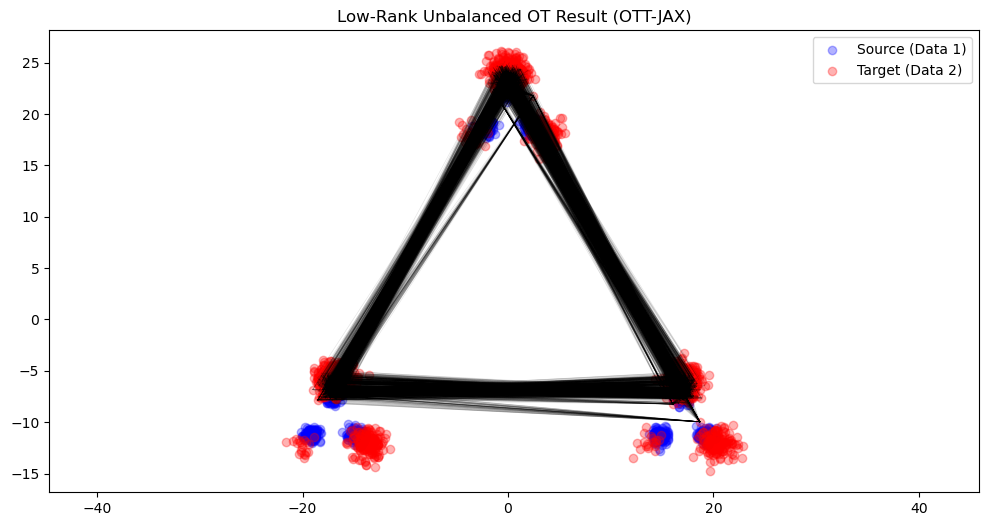


=== WFR Distance Computation ===
WFR^2: 5545.874265
WFR distance: 74.470627


In [15]:
""" 
Low-Rank UOT (ott-jax)
delta = 1
"""
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ot

# ===== JAX / OTT =====
import jax
import jax.numpy as jnp
from ott.geometry import geometry
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn_lr

# ================= 0. 数据准备 =================
# df_final = pd.read_csv('simulated_data_hierarchical_unbalanced.csv') 

df_src = df_final[df_final['dataset_id'] == 1].copy().reset_index(drop=True)
df_tgt = df_final[df_final['dataset_id'] == 2].copy().reset_index(drop=True)

X_src = df_src[['x', 'y']].values
X_tgt = df_tgt[['x', 'y']].values

n_src = len(df_src)
n_tgt = len(df_tgt)

# 权重（与原代码一致）
w_points_src = np.ones(n_src)
w_points_tgt = np.ones(n_tgt)

# ================= 1. 成本矩阵 =================
print("\n--- Running Low-Rank UOT (OTT-JAX) ---")

delta = 1.0

norm_2_dist = ot.dist(X_src, X_tgt, metric='euclidean')
cos_sq = np.cos(np.minimum(norm_2_dist / (2 * delta), np.pi/2))**2
M_points = -np.log(np.where(cos_sq == 0, 1e-10, cos_sq))

# ================= 2. 转 JAX =================
# 注意：ott 要求概率分布（归一化）
a = jnp.array(w_points_src / np.sum(w_points_src))
b = jnp.array(w_points_tgt / np.sum(w_points_tgt))
C = jnp.array(M_points)

# ================= 3. Low-Rank UOT =================
print("Solving Low-Rank UOT (unbalanced)...")

start_time = time.perf_counter()

rank = 100          # 低秩
epsilon = 0.1       # entropic regularization
tau = 0.9           # < 1 → unbalanced

geom = geometry.Geometry(cost_matrix=C, epsilon=epsilon)

# 启 unbalanced
problem = linear_problem.LinearProblem(
    geom,
    a=a,
    b=b,
    tau_a=tau,
    tau_b=tau
)

solver = sinkhorn_lr.LRSinkhorn(rank=rank)

out = solver(problem)

# coupling
gamma_lr = np.array(out.matrix)

end_time = time.perf_counter()
print(f"代码运行耗时: {end_time - start_time:.6f} 秒")

# ================= 4. 可视化 =================
plt.figure(figsize=(12, 6))

plt.scatter(X_src[:, 0], X_src[:, 1], c='blue', alpha=0.3, label='Source (Data 1)')
plt.scatter(X_tgt[:, 0], X_tgt[:, 1], c='red', alpha=0.3, label='Target (Data 2)')

mx = gamma_lr.max()
idx_struct = np.argwhere(gamma_lr > mx * 0.77)

print(f"Plotting {len(idx_struct)} connections...")

for i, j in idx_struct:
    plt.plot(
        [X_src[i, 0], X_tgt[j, 0]],
        [X_src[i, 1], X_tgt[j, 1]],
        c='k', alpha=0.1, linewidth=0.5
    )

plt.title("Low-Rank Unbalanced OT Result (OTT-JAX)")
plt.legend()
plt.axis('equal')
plt.show()

# ================= 5. WFR 距离 =================
wfr_squared, wfr_distance = compute_wfr_distance_unbalanced(
    gamma=gamma_lr,
    mu_src=w_points_src,
    mu_tgt=w_points_tgt,
    M_points=M_points,
    delta=delta
)

print(f"\n=== WFR Distance Computation ===")
print(f"WFR^2: {wfr_squared:.6f}")
print(f"WFR distance: {wfr_distance:.6f}")

In [16]:
def compute_uot_sparse(
    a,
    b,
    M,  # torch.sparse_coo_tensor
    reg_m,
    c=None,
    reg=0.0,
    div="kl",
    G0=None,
    numItermax=1000,
    stopThr=1e-9,
    verbose=False,
    log=False,
):
    import torch
    from ot.utils import get_parameter_pair

    assert torch.is_tensor(M) and M.is_sparse, "M must be torch sparse COO tensor"

    device = M.device
    dtype = M.dtype

    # ===== coalesce（必须）=====
    M = M.coalesce()
    indices = M.indices()  # [2, nnz]
    row = indices[0]
    col = indices[1]
    M_data = M.values()

    dim_a, dim_b = M.shape

    # ===== a, b =====
    a = torch.as_tensor(a, device=device, dtype=dtype).flatten()
    b = torch.as_tensor(b, device=device, dtype=dtype).flatten()

    if a.numel() == 0:
        a = torch.ones(dim_a, device=device, dtype=dtype) / dim_a
    if b.numel() == 0:
        b = torch.ones(dim_b, device=device, dtype=dtype) / dim_b

    reg_m1, reg_m2 = get_parameter_pair(reg_m)

    # ===== 初始化 G =====
    if G0 is None:
        G_data = a[row] * b[col]
    else:
        if G0.is_sparse:
            G_data = G0.coalesce().values()
        else:
            G_data = G0[row, col]

    # ===== Kernel K =====
    div = div.lower()

    if div == "kl":
        sum_r = reg + reg_m1 + reg_m2
        r1 = reg_m1 / sum_r
        r2 = reg_m2 / sum_r
        r = reg / sum_r

        # 数值稳定（防爆）
        scaled_M = torch.clamp(M_data / sum_r, max=50.0)

        K_data = (
            (a[row] ** r1)
            * (b[col] ** r2)
            * torch.exp(-scaled_M)
        )

        if reg > 0:
            if c is None:
                c_data = a[row] * b[col]
            else:
                c = c.coalesce()
                c_data = c.values()
            K_data = K_data * (c_data ** r)

    elif div == "l2":
        K_data = (
            reg_m1 * a[row]
            + reg_m2 * b[col]
            - M_data
        )
        K_data = torch.clamp(K_data, min=0.0)

    else:
        raise ValueError("Unknown div")

    # ===== log =====
    if log:
        log_dict = {"err": []}

    # ===== 主循环 =====
    for i in range(numItermax):
        G_prev = G_data.clone()

        # ===== marginals（关键：scatter）=====
        u = torch.zeros(dim_a, device=device, dtype=dtype)
        v = torch.zeros(dim_b, device=device, dtype=dtype)

        u.index_add_(0, row, G_data)
        v.index_add_(0, col, G_data)

        if div == "kl":
            u_pow = torch.pow(u, r1)
            v_pow = torch.pow(v, r2)

            denom = u_pow[row] * v_pow[col] + 1e-16

            G_power = torch.pow(G_data, r1 + r2)

            G_data = K_data * G_power / denom

        elif div == "l2":
            denom = (
                reg_m1 * u[row]
                + reg_m2 * v[col]
                + reg * G_data
                + 1e-16
            )
            G_data = K_data * G_data / denom

        # ===== 收敛 =====
        err = torch.norm(G_data - G_prev)

        if log:
            log_dict["err"].append(err.item())

        if verbose:
            print(f"{i:5d}|{err:.6e}|")

        if err.item() < stopThr:
            break

    # ===== 输出 sparse G =====
    G = torch.sparse_coo_tensor(
        indices,
        G_data,
        size=(dim_a, dim_b),
        device=device,
        dtype=dtype,
    )

    if log:
        return G.coalesce(), log_dict
    else:
        return G.coalesce()

--- Running Level 1: Macro Scale OT ---
代码运行耗时: 0.016987 秒
Macro Transport Plan:
 [[130.856   0.      0.   ]
 [  0.    148.029   0.   ]
 [  0.      0.    138.811]]

--- Running Level 2: Micro Scale OT ---
代码运行耗时: 0.017485 秒


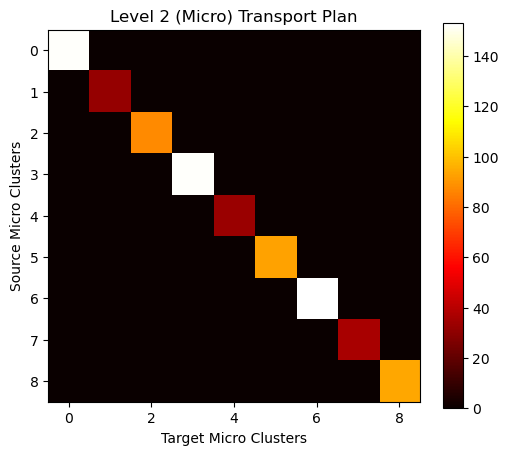


--- Running Level 3: Point Scale OT (Sparse COO) ---
稀疏矩阵构建完成. Shape: (900, 1860)
非零元素 (NNZ): 186000
稀疏度: 11.1111%
Solving final point-wise OT with Sparse Matrix...
代码运行耗时: 0.224252 秒
Plotting 4053 connections...


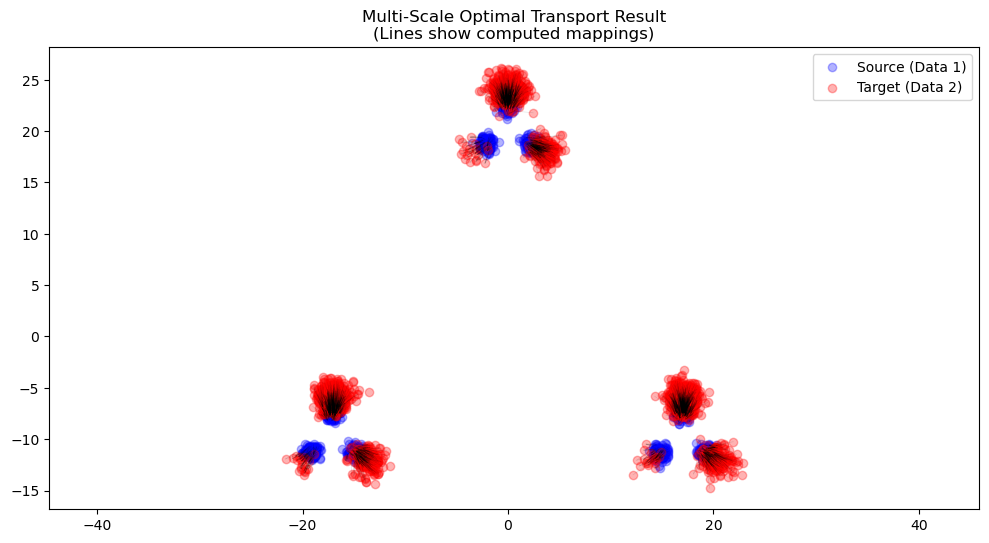


=== WFR Distance Computation ===
WFR^2: 1999.667596
WFR distance: 44.717643


In [17]:
""" 
MS-UOT
delta = 1 
"""

import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ot  # Python Optimal Transport library
from scipy.spatial.distance import cdist
from scipy import sparse

# from ot_extensions import mm_unbalanced_sparse

# ================= 0. 数据准备 (沿用上一段代码生成的数据) =================
# 假设 df_final 已经在内存中，或者我们重新加载它

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

# 分离 Source (Data 1) 和 Target (Data 2)
df_src = df_final[df_final['dataset_id'] == 1].copy().reset_index(drop=True)
df_tgt = df_final[df_final['dataset_id'] == 2].copy().reset_index(drop=True)

# 提取坐标数组
X_src = df_src[['x', 'y']].values
X_tgt = df_tgt[['x', 'y']].values


# 辅助函数：计算质心和权重
def get_cluster_stats(df, cluster_col):
    """
    计算指定层级 cluster 的质心(centroids) 和 权重(weights)
    权重 = 点的数量 / 总点数
    """
    groups = df.groupby(cluster_col)
    centroids = groups[['x', 'y']].mean().values
    counts = groups.size().values

    """ 
    clz:
    此处修改，不再归一化，引入非平衡信息
    """
    weights = counts.astype(float)  # 直接用点数作为质量
    # weights = counts / counts.sum()
    ids = groups.groups.keys()  # 保持顺序
    return centroids, weights, list(ids)


# ================= 1. Level 1: Macro Scale (大团簇级别) =================
print("--- Running Level 1: Macro Scale OT ---")

C_macro_src, w_macro_src, macro_ids_src = get_cluster_stats(df_src, 'macro_cluster_id')
C_macro_tgt, w_macro_tgt, macro_ids_tgt = get_cluster_stats(df_tgt, 'macro_cluster_id')

delta = 1

norm_2_dist_macro = ot.dist(C_macro_src, C_macro_tgt, metric='euclidean')
cos_sq_macro = np.cos(np.minimum(norm_2_dist_macro / (2 * delta), np.pi/2))**2
M_macro = -np.log(np.where(cos_sq_macro == 0, 1e-10, cos_sq_macro))

start_time = time.perf_counter()

gamma_macro = ot.unbalanced.mm_unbalanced(
    w_macro_src, w_macro_tgt, M_macro, reg_m=[1.0, 1.0]
)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"代码运行耗时: {elapsed_time:.6f} 秒")

print("Macro Transport Plan:\n", np.round(gamma_macro, 3))


# ================= 2. Level 2: Micro Scale (小团簇级别) =================
print("\n--- Running Level 2: Micro Scale OT ---")

C_micro_src, w_micro_src, micro_ids_src = get_cluster_stats(df_src, 'micro_cluster_id')
C_micro_tgt, w_micro_tgt, micro_ids_tgt = get_cluster_stats(df_tgt, 'micro_cluster_id')

norm_2_dist_micro = ot.dist(C_micro_src, C_micro_tgt, metric='euclidean')
cos_sq_micro = np.cos(np.minimum(norm_2_dist_micro / (2 * delta), np.pi/2))**2
M_micro = -np.log(np.where(cos_sq_micro == 0, 1e-10, cos_sq_micro))


micro_to_macro_src = df_src.groupby('micro_cluster_id')['macro_cluster_id'].first().to_dict()
micro_to_macro_tgt = df_tgt.groupby('micro_cluster_id')['macro_cluster_id'].first().to_dict()

threshold = 1e-8

for i, m_src in enumerate(micro_ids_src):
    parent_src = micro_to_macro_src[m_src]
    for j, m_tgt in enumerate(micro_ids_tgt):
        parent_tgt = micro_to_macro_tgt[m_tgt]

        if gamma_macro[parent_src, parent_tgt] < threshold:
            M_micro[i, j] = np.inf


start_time = time.perf_counter()

gamma_micro = ot.unbalanced.mm_unbalanced(
    w_micro_src, w_micro_tgt, M_micro, reg_m=[1.0, 1.0]
)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"代码运行耗时: {elapsed_time:.6f} 秒")

plt.figure(figsize=(6, 5))
plt.imshow(gamma_micro, cmap='hot', interpolation='nearest')
plt.title("Level 2 (Micro) Transport Plan")
plt.xlabel("Target Micro Clusters")
plt.ylabel("Source Micro Clusters")
plt.colorbar()
plt.show()


# ================= 3. Level 3: point Scale (点级别) =================
print("\n--- Running Level 3: Point Scale OT (Sparse COO) ---")

X_src = df_src[['x', 'y']].values
X_tgt = df_tgt[['x', 'y']].values

n_src = len(df_src)
n_tgt = len(df_tgt)

w_points_src = np.ones(n_src)
w_points_tgt = np.ones(n_tgt)


def get_micro_idx_to_point_indices(df, micro_ids_order, cluster_col='micro_cluster_id'):
    group_indices = df.groupby(cluster_col).indices

    idx_map = {}
    for i, mid in enumerate(micro_ids_order):
        if mid in group_indices:
            idx_map[i] = group_indices[mid]
        else:
            idx_map[i] = []
    return idx_map


map_micro_to_pts_src = get_micro_idx_to_point_indices(df_src, micro_ids_src)
map_micro_to_pts_tgt = get_micro_idx_to_point_indices(df_tgt, micro_ids_tgt)


threshold = 1e-8
active_micro_pairs = np.argwhere(gamma_micro > threshold)

rows = []
cols = []
data = []

for m_src_idx, m_tgt_idx in active_micro_pairs:

    src_pt_indices = map_micro_to_pts_src.get(m_src_idx, [])
    tgt_pt_indices = map_micro_to_pts_tgt.get(m_tgt_idx, [])

    if len(src_pt_indices) == 0 or len(tgt_pt_indices) == 0:
        continue

    block_X_src = X_src[src_pt_indices]
    block_X_tgt = X_tgt[tgt_pt_indices]

    norm_2_dist_point = ot.dist(block_X_src, block_X_tgt, metric='euclidean')
    cos_sq_point = np.cos(np.minimum(norm_2_dist_point / (2 * delta), np.pi/2))**2
    dists = -np.log(np.where(cos_sq_point == 0, 1e-10, cos_sq_point))

    grid_r, grid_c = np.meshgrid(src_pt_indices, tgt_pt_indices, indexing='ij')

    rows.append(grid_r.flatten())
    cols.append(grid_c.flatten())
    data.append(dists.flatten())


if data:
    all_rows = np.concatenate(rows)
    all_cols = np.concatenate(cols)
    all_data = np.concatenate(data)

    M_points_sparse = sparse.coo_matrix(
        (all_data, (all_rows, all_cols)),
        shape=(n_src, n_tgt)
    )
else:
    M_points_sparse = sparse.coo_matrix((n_src, n_tgt))


print(f"稀疏矩阵构建完成. Shape: {M_points_sparse.shape}")
print(f"非零元素 (NNZ): {M_points_sparse.nnz}")
print(f"稀疏度: {M_points_sparse.nnz / (n_src * n_tgt):.4%}")


print("Solving final point-wise OT with Sparse Matrix...")

w_points_src_cuda = torch.from_numpy(w_points_src).to(device)
w_points_tgt_cuda = torch.from_numpy(w_points_tgt).to(device)

indices = torch.from_numpy(
    np.vstack((M_points_sparse.row, M_points_sparse.col))
).long().to(device)

values = torch.from_numpy(M_points_sparse.data).to(device)

M_points_sparse_cuda = torch.sparse_coo_tensor(
    indices, values, M_points_sparse.shape, device=device
)

start_time = time.perf_counter()

gamma_points = compute_uot_sparse(
    w_points_src_cuda,
    w_points_tgt_cuda,
    M_points_sparse_cuda,
    reg_m=[1.0, 1.0]
)

end_time = time.perf_counter()
print(f"代码运行耗时: {end_time - start_time:.6f} 秒")


plt.figure(figsize=(12, 6))

plt.scatter(X_src[:, 0], X_src[:, 1], c='blue', alpha=0.3, label='Source (Data 1)')
plt.scatter(X_tgt[:, 0], X_tgt[:, 1], c='red', alpha=0.3, label='Target (Data 2)')

gamma_points = gamma_points.cpu().to_dense().numpy()

mx = gamma_points.max()
idx_struct = np.argwhere(gamma_points > mx * 0.05)

print(f"Plotting {len(idx_struct)} connections...")

for i, j in idx_struct:
    plt.plot(
        [X_src[i, 0], X_tgt[j, 0]],
        [X_src[i, 1], X_tgt[j, 1]],
        c='k',
        alpha=0.1,
        linewidth=0.5
    )

plt.title("Multi-Scale Optimal Transport Result\n(Lines show computed mappings)")
plt.legend()
plt.axis('equal')
plt.show()


wfr_squared, wfr_distance = compute_wfr_distance_unbalanced(
    gamma=gamma_points,
    mu_src=w_points_src,
    mu_tgt=w_points_tgt,
    M_points=M_points_sparse_cuda.cpu().to_dense().numpy(),
    delta=delta
)

print(f"\n=== WFR Distance Computation ===")
print(f"WFR^2: {wfr_squared:.6f}")
print(f"WFR distance: {wfr_distance:.6f}")

--- Running Level 1: Macro Scale OT ---
代码运行耗时: 0.017278 秒
Macro Transport Plan:
 [[130.856   0.      0.   ]
 [  0.    148.029   0.   ]
 [  0.      0.    138.811]]

--- Running Level 2: Micro Scale OT ---
代码运行耗时: 0.017354 秒


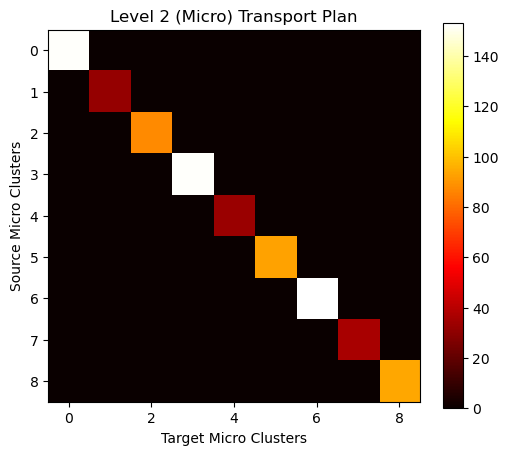


--- Running Level 3: Point Scale (Heuristic Expansion) ---
Sparse gamma_points NNZ: 186000
Plotting 6000 connections...


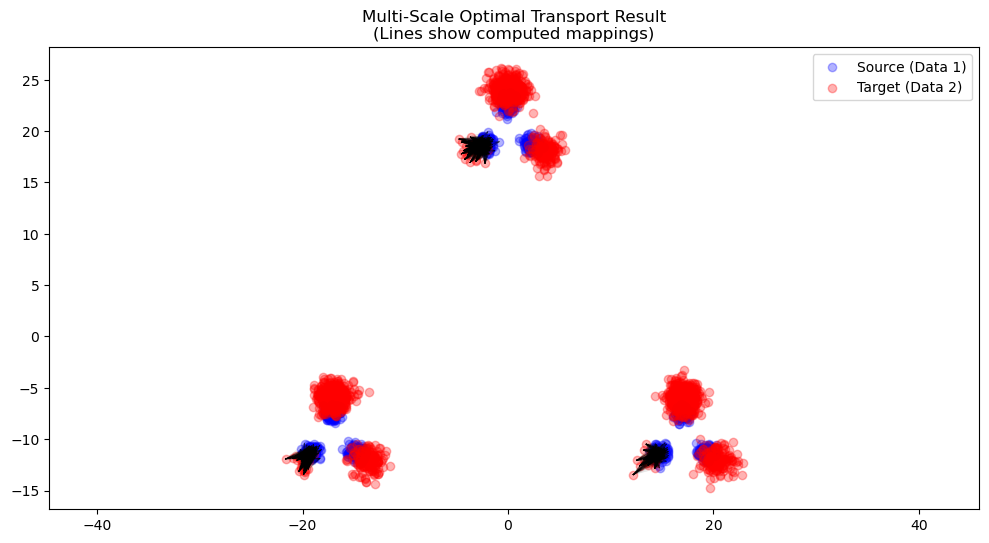


=== WFR Distance Computation ===
WFR^2: 9944.376723
WFR distance: 99.721496


In [24]:
"""
MS-UOT-independent 
delta = 1 
"""

import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ot  # Python Optimal Transport library
from scipy.spatial.distance import cdist
from scipy import sparse

# from ot_extensions import mm_unbalanced_sparse

# ================= 0. 数据准备 (沿用上一段代码生成的数据) =================
# 假设 df_final 已经在内存中，或者我们重新加载它

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

# 分离 Source (Data 1) 和 Target (Data 2)
df_src = df_final[df_final['dataset_id'] == 1].copy().reset_index(drop=True)
df_tgt = df_final[df_final['dataset_id'] == 2].copy().reset_index(drop=True)

# 提取坐标数组
X_src = df_src[['x', 'y']].values
X_tgt = df_tgt[['x', 'y']].values


# 辅助函数：计算质心和权重
def get_cluster_stats(df, cluster_col):
    """
    计算指定层级 cluster 的质心(centroids) 和 权重(weights)
    权重 = 点的数量 / 总点数
    """
    groups = df.groupby(cluster_col)
    centroids = groups[['x', 'y']].mean().values
    counts = groups.size().values

    """ 
    clz:
    此处修改，不再归一化，引入非平衡信息
    """
    weights = counts.astype(float)  # 直接用点数作为质量
    # weights = counts / counts.sum()
    ids = groups.groups.keys()  # 保持顺序
    return centroids, weights, list(ids)


# ================= 1. Level 1: Macro Scale (大团簇级别) =================
print("--- Running Level 1: Macro Scale OT ---")

C_macro_src, w_macro_src, macro_ids_src = get_cluster_stats(df_src, 'macro_cluster_id')
C_macro_tgt, w_macro_tgt, macro_ids_tgt = get_cluster_stats(df_tgt, 'macro_cluster_id')

delta = 1

norm_2_dist_macro = ot.dist(C_macro_src, C_macro_tgt, metric='euclidean')
cos_sq_macro = np.cos(np.minimum(norm_2_dist_macro / (2 * delta), np.pi/2))**2
M_macro = -np.log(np.where(cos_sq_macro == 0, 1e-10, cos_sq_macro))

start_time = time.perf_counter()

gamma_macro = ot.unbalanced.mm_unbalanced(
    w_macro_src, w_macro_tgt, M_macro, reg_m=[1.0, 1.0]
)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"代码运行耗时: {elapsed_time:.6f} 秒")

print("Macro Transport Plan:\n", np.round(gamma_macro, 3))


# ================= 2. Level 2: Micro Scale (小团簇级别) =================
print("\n--- Running Level 2: Micro Scale OT ---")

C_micro_src, w_micro_src, micro_ids_src = get_cluster_stats(df_src, 'micro_cluster_id')
C_micro_tgt, w_micro_tgt, micro_ids_tgt = get_cluster_stats(df_tgt, 'micro_cluster_id')

norm_2_dist_micro = ot.dist(C_micro_src, C_micro_tgt, metric='euclidean')
cos_sq_micro = np.cos(np.minimum(norm_2_dist_micro / (2 * delta), np.pi/2))**2
M_micro = -np.log(np.where(cos_sq_micro == 0, 1e-10, cos_sq_micro))


micro_to_macro_src = df_src.groupby('micro_cluster_id')['macro_cluster_id'].first().to_dict()
micro_to_macro_tgt = df_tgt.groupby('micro_cluster_id')['macro_cluster_id'].first().to_dict()

threshold = 1e-8

for i, m_src in enumerate(micro_ids_src):
    parent_src = micro_to_macro_src[m_src]
    for j, m_tgt in enumerate(micro_ids_tgt):
        parent_tgt = micro_to_macro_tgt[m_tgt]

        if gamma_macro[parent_src, parent_tgt] < threshold:
            M_micro[i, j] = np.inf


start_time = time.perf_counter()

gamma_micro = ot.unbalanced.mm_unbalanced(
    w_micro_src, w_micro_tgt, M_micro, reg_m=[1.0, 1.0]
)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"代码运行耗时: {elapsed_time:.6f} 秒")

plt.figure(figsize=(6, 5))
plt.imshow(gamma_micro, cmap='hot', interpolation='nearest')
plt.title("Level 2 (Micro) Transport Plan")
plt.xlabel("Target Micro Clusters")
plt.ylabel("Source Micro Clusters")
plt.colorbar()
plt.show()


# ================= 3. Level 3: point Scale (Heuristic) =================
print("\n--- Running Level 3: Point Scale (Heuristic Expansion) ---")

n_src = len(df_src)
n_tgt = len(df_tgt)

# -------------------------------------------------------------------------
# 1. 建立 micro → point 映射（保留你原来的函数）
# -------------------------------------------------------------------------
def get_micro_idx_to_point_indices(df, micro_ids_order, cluster_col='micro_cluster_id'):
    group_indices = df.groupby(cluster_col).indices
    idx_map = {}
    for i, mid in enumerate(micro_ids_order):
        if mid in group_indices:
            idx_map[i] = group_indices[mid]
        else:
            idx_map[i] = []
    return idx_map

map_micro_to_pts_src = get_micro_idx_to_point_indices(df_src, micro_ids_src)
map_micro_to_pts_tgt = get_micro_idx_to_point_indices(df_tgt, micro_ids_tgt)

# -------------------------------------------------------------------------
# 2. heuristic 展开 gamma_micro → gamma_points（稀疏）
# -------------------------------------------------------------------------
threshold = 1e-8
active_pairs = np.argwhere(gamma_micro > threshold)

rows = []
cols = []
data = []

for m_src_idx, m_tgt_idx in active_pairs:

    src_pts = map_micro_to_pts_src.get(m_src_idx, [])
    tgt_pts = map_micro_to_pts_tgt.get(m_tgt_idx, [])

    if len(src_pts) == 0 or len(tgt_pts) == 0:
        continue

    n_s = len(src_pts)
    n_t = len(tgt_pts)

    # 均匀展开（与你给的完全一致）
    val = gamma_micro[m_src_idx, m_tgt_idx] / (n_s * n_t)

    grid_r, grid_c = np.meshgrid(src_pts, tgt_pts, indexing='ij')

    rows.append(grid_r.flatten())
    cols.append(grid_c.flatten())
    data.append(np.full(n_s * n_t, val))

# -------------------------------------------------------------------------
# 3. 构建 sparse gamma_points（torch COO）
# -------------------------------------------------------------------------
if data:
    all_rows = np.concatenate(rows)
    all_cols = np.concatenate(cols)
    all_data = np.concatenate(data)

    indices = torch.from_numpy(
        np.vstack((all_rows, all_cols))
    ).long().to(device)

    values = torch.from_numpy(all_data).float().to(device)

    gamma_points = torch.sparse_coo_tensor(
        indices, values, (n_src, n_tgt), device=device
    ).coalesce()
else:
    gamma_points = torch.sparse_coo_tensor(
        torch.zeros((2, 0), dtype=torch.long, device=device),
        torch.zeros(0, device=device),
        (n_src, n_tgt)
    )

print(f"Sparse gamma_points NNZ: {gamma_points._nnz()}")

# -------------------------------------------------------------------------
# 4. 转 dense（用于后续可视化 & WFR）
# -------------------------------------------------------------------------
gamma_points = gamma_points.cpu().to_dense().numpy()

plt.figure(figsize=(12, 6))

plt.scatter(X_src[:, 0], X_src[:, 1], c='blue', alpha=0.3, label='Source (Data 1)')
plt.scatter(X_tgt[:, 0], X_tgt[:, 1], c='red', alpha=0.3, label='Target (Data 2)')

mx = gamma_points.max()
idx_struct = np.argwhere(gamma_points > mx * 0.5)

print(f"Plotting {len(idx_struct)} connections...")

for i, j in idx_struct:
    plt.plot(
        [X_src[i, 0], X_tgt[j, 0]],
        [X_src[i, 1], X_tgt[j, 1]],
        c='k',
        alpha=0.1,
        linewidth=0.5
    )

plt.title("Multi-Scale Optimal Transport Result\n(Lines show computed mappings)")
plt.legend()
plt.axis('equal')
plt.show()


wfr_squared, wfr_distance = compute_wfr_distance_unbalanced(
    gamma=gamma_points,
    mu_src=w_points_src,
    mu_tgt=w_points_tgt,
    M_points=M_points_sparse_cuda.cpu().to_dense().numpy(),
    delta=delta
)

print(f"\n=== WFR Distance Computation ===")
print(f"WFR^2: {wfr_squared:.6f}")
print(f"WFR distance: {wfr_distance:.6f}")